# Tutorial zur Datenvisualisierung

Python ist aktuell die Programmiersprache der Wahl, wenn es um die Aufbereitung und Visualisierung von Daten geht. Python stellt dafür mehrere Libraries zur Verfügung. In diesem Tutorial kommen Pandas, Numpy und Matplotlib zur Anwendung. Entsprechend werden die drei Libraries in der ersten Code-Zelle importiert. Aus Matplotlib wird zusätzlich das Modul `matplotlib.dates` importiert, das später für die Beschriftung der Zeitachse gebraucht wird.

## Aufbau einer Data-Science-Arbeit

Dieses Notebook ist nicht nur ein Tutorial, sondern zugleich ein Beispiel dafür, wie eine kleine Data-Science-Arbeit aufgebaut ist. Der Aufbau folgt einem Muster, das sich auf beliebige eigene Themen übertragen lässt:

1. **Fragestellung und Hypothese** – Was will ich wissen, und was erwarte ich? (mit Bezug zur Theorie)
2. **Datenbeschaffung und Bereinigung** – Woher stammen die Daten, und wie werden sie eingelesen und gesäubert?
3. **Fusionieren der Daten** – Wie werden mehrere Datenquellen korrekt zusammengeführt?
4. **Analyse** – Welche Kennzahl beantwortet die Fragestellung, und wie wird sie berechnet?
5. **Visualisierung** – Wie wird das Resultat verständlich dargestellt?
6. **Interpretation und Fazit** – Was bedeutet das Resultat für die Hypothese, und wo liegen die Grenzen der Arbeit?
7. **Quellen** – Welche Daten, welche Literatur und welche Dokumentationen wurden verwendet?

Nicht jede Arbeit braucht mehrere Datenquellen – dann entfällt Kapitel 3. Die übrigen Elemente gehören aber in jede Arbeit.

**Qualitätskriterium Reproduzierbarkeit:** Eine Data-Science-Arbeit gilt erst dann als fertig, wenn das Notebook nach *Kernel → Restart & Run All* ohne Fehler von oben nach unten durchläuft und alle Tabellen und Grafiken korrekt erzeugt. Wer Zellen während der Entwicklung in wechselnder Reihenfolge ausgeführt hat, merkt das spätestens bei diesem Test.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates  # Hilfsmodul für die Beschriftung von Zeitachsen

## 1 Fragestellung und Hypothese

Das Tutorial orientiert sich an der Quantitätsgleichung aus der Volkswirtschaftslehre (vgl. Samuelson/Nordhaus, Volkswirtschaftslehre, Kapitel zu Geld und Geldpolitik). Die Quantitätsgleichung geht davon aus, dass die Geldmenge multipliziert mit der Umlaufgeschwindigkeit des Geldes gleich dem Produkt aus Preisniveau und realem BIP sei.

$$
M \cdot V = P \cdot Y
$$

Wobei

- $M$ für die Geldmenge,
- $V$ für die Umlaufgeschwindigkeit des Geldes,
- $P$ für das Preisniveau sowie
- $Y$ für das reale BIP steht.

Ziel des Tutorials ist es, die Entwicklung von $V$ für die Schweiz seit der Jahrtausendwende zu visualisieren. Anschliessend wird anhand der Daten die Hypothese geprüft, dass die Umlaufgeschwindigkeit des Geldes nach wirtschaftlichen Krisen steigt.

Die Daten für $V$ werden durch die amtlichen Statistiken nicht direkt zur Verfügung gestellt, d.h. $V$ muss aus $M$, $P$ und $Y$ berechnet werden. Die Quantitätsgleichung wird dazu nach $V$ aufgelöst:

$$
V = \frac{P \cdot Y}{M}
$$

## 2 Datenbeschaffung und Bereinigung

Amtliche Statistiken kommen selten in einem Format, das sich direkt einlesen lässt: Titelzeilen, Fussnoten, Leerspalten und nicht benötigte historische Daten stehen den eigentlichen Werten im Weg. Argumente wie `skiprows=91` oder `usecols='HL:TQ'` in den folgenden Zellen wirken deshalb auf den ersten Blick wie Zauberzahlen – sie sind es aber nicht. Sie werden in drei Schritten ermittelt:

1. Die Datei zuerst im Original anschauen (CSV-Dateien in einem Texteditor, Excel-Dateien in Excel oder LibreOffice): Wo beginnen die Daten? Welche Spalten werden gebraucht? Welches Trennzeichen wird verwendet?
2. Die Datei testweise ohne optionale Argumente einlesen und mit `df.head()` prüfen, was Pandas daraus macht.
3. Die Argumente schrittweise ergänzen, bis der DataFrame die gewünschte Form hat.

Bei einer eigenen Arbeit gehört dieses Vorgehen zum Handwerk: Niemand kennt die richtigen Werte im Voraus – man ermittelt sie durch Inspektion der Rohdaten.

### 2.1 Geldmenge M1 (SNB)

Die Daten für die Geldmenge werden durch die Schweizerische Nationalbank (SNB) zur Verfügung gestellt. Zur Vereinfachung verwenden wir hier für die Geldmenge die Geldmenge M1. Die entsprechenden Daten werden von der SNB auf deren [Datenportal](https://data.snb.ch/de/topics/snb/cube/snbmonagg) zur Verfügung gestellt. Die Daten können vorgefiltert als CSV-Datei heruntergeladen werden. Die CSV-Datei kann dann zur Weiterverarbeitung in einen Pandas DataFrame gelesen werden. Ein DataFrame ist dabei ein Python-Äquivalent einer Excel-Tabelle.

Die Syntax für das Einlesen der CSV-Datei lautet dabei im Grundsatz `df = pd.read_csv('data.csv')`. Dabei steht `'data.csv'` für den Pfad zur CSV-Datei als String. Die Bedeutung der verwendeten optionalen Argumente wird direkt in der Code-Zelle als Kommentar erklärt (vgl. dazu auch die [Pandas-Dokumentation zu `read_csv`](https://pandas.pydata.org/docs/reference/api/pandas.read_csv.html)).

In [3]:
m1 = pd.read_csv('260724_m1_snb.csv',  # Der DataFrame wird mit dem Inhalt bezeichnet
                 skiprows=4,           # Die datenfreien Zeilen werden ignoriert
                 header=None,          # Es werden keine Header eingelesen
                 names=['Datum', 'Typ', 'Drop', 'M1'], # Selbst festgelegte Header
                 sep=';')              # Da ein Semikolon als Trennzeichen verwendet wird,
                                       # wird das hier so angegeben.

Mit `df.head()` kann man sich einen Überblick über die Darstellung der Daten verschaffen. Per default werden die ersten fünf Zeilen des DataFrames angezeigt. Man kann eine davon abweichende Zeilenzahl als Argument übergeben.

In [4]:
m1.head()

,Datum,Typ,Drop,M1
0,2000-01,B,GM1,212697.000000
1,2000-01,VV,GM1,5.668523
2,2000-02,B,GM1,209974.000000
3,2000-02,VV,GM1,1.869785
4,2000-03,B,GM1,206603.000000


Unser DataFrame hat nicht nur Zeilen mit dem Bestand von M1 für jeden Monat (B), sondern auch noch Zeilen mit der Veränderung gegenüber dem Vormonat (VV). Wir brauchen aber ausschliesslich die B-Zeilen. Entsprechend müssen wir den DataFrame bereinigen. Glücklicherweise können Pandas DataFrames praktisch beliebig gefiltert werden.

Eine Möglichkeit, den DataFrame zu filtern ist das 'boolean indexing'. Dabei weise ich den DataFrame an, nur jene Zeilen zu verwenden, welche eine bestimmte Bedingung erfüllen. In unserem Fall brauchen wir ausschliesslich jene Zeilen, welche in der Spalte 'Typ' (in der Originaldatei der SNB heisst diese Spalte 'D0') den Wert 'B' enthalten. Da für unseren Zweck die Veränderung gegenüber dem Vormonat nicht von Interesse ist, können wir `m1` mit den gefilterten Werten überschreiben.

In [5]:
m1 = m1[m1['Typ'] == 'B']
m1.head()

,Datum,Typ,Drop,M1
0,2000-01,B,GM1,212697.0
2,2000-02,B,GM1,209974.0
4,2000-03,B,GM1,206603.0
6,2000-04,B,GM1,206650.0
8,2000-05,B,GM1,206826.0


### 2.2 Reales BIP (SECO)

Die Daten zum BIP werden durch das Staatssekretariat für Wirtschaft (SECO) als Excel-Tabelle [zum Download angeboten](https://www.seco.admin.ch/de/bruttoinlandprodukt#Tabellen). Pandas kann nicht nur CSV-Dateien als DataFrame einlesen. Das ist auch mit Excel-Tabellen möglich. Wir verwenden das Tabellenblatt `real_q` mit dem realen BIP pro Quartal, weil in der Quantitätsgleichung $Y$ für das reale BIP steht. Die einzelnen Argumente werden direkt in der Code-Zelle als Kommentar erläutert.

Die Werte für `usecols` und `skiprows` wurden nach dem in Kapitel 2 beschriebenen Vorgehen durch Inspektion der Excel-Datei ermittelt: `skiprows=91` überspringt neben den Titelzeilen auch die Quartale vor dem Jahr 2000.

In [6]:
bip = pd.read_excel(
    '260724_bip_seco.xlsx', # Pfad zur Datei
    sheet_name='real_q',    # Name des einzulesenden Tabellenblattes
    usecols='A:C',          # Einzulesende Spalten
    skiprows=91,            # Nicht einzulesende Zeilen (Daten vor dem Jahr 2000)
    header=None,            # Keine Header einlesen
    names=['Jahr', 'Quartal', 'BIP'] # Namen der Header
)

In [7]:
bip.head()

,Jahr,Quartal,BIP
0,2000,1,127011.608008
1,2000,2,127402.453265
2,2000,3,128388.227872
3,2000,4,129981.564708
4,2001,1,129891.827737


### 2.3 Landesindex der Konsumentenpreise (BFS)

Die Daten zum Landesindex der Konsumentenpreise (LIK) werden durch das Bundesamt für Statistik als Excel-Tabelle zum Download zur Verfügung gestellt. Für den Import werden die gleichen Argumente verwendet wie beim Import der BIP-Daten. Allerdings sind die relevanten Daten als Zeile organisiert. Um diese als Spalte anzuordnen, muss der DataFrame transponiert werden. Dies geschieht mit dem `.T` am Ende des Import-Statements.

Auch hier stammen `usecols='HL:TQ'`, `skiprows=3` und `nrows=2` aus der Inspektion der Datei: Die relevanten Werte ab Januar 2000 stehen in genau zwei Zeilen dieser Spaltenbereiche.

In [8]:
lik = pd.read_excel(
    '260724_lik_bfs.xlsx',
    sheet_name=0,
    usecols='HL:TQ',
    skiprows=3,
    nrows=2,
    header=None
).T

lik.columns = ['Monat', 'LIK']
lik = lik.reset_index(drop=True)
lik.head()

,Monat,LIK
0,2000-01-01 00:00:00,86.5697
1,2000-02-01 00:00:00,86.8951
2,2000-03-01 00:00:00,86.8654
3,2000-04-01 00:00:00,86.9413
4,2000-05-01 00:00:00,86.8986


## 3 Fusionieren der Daten

Die drei DataFrames müssen nun zu einem einzigen fusioniert werden. Dabei stellen sich zwei Probleme: Erstens rapportieren zwei DataFrames die Daten monatlich und einer quartalsweise. Zweitens sind die Statistiken unterschiedlich aktuell – die Geldmenge und der LIK liegen bereits für spätere Quartale vor als das BIP.

Wir lösen beide Probleme, indem wir in allen drei DataFrames einen gemeinsamen Schlüssel aus Jahr und Quartal bilden und die DataFrames mit `pd.merge()` über diesen Schlüssel zusammenführen. Bei einem `merge` ordnet Pandas jede Zeile anhand des Schlüssels zu – nicht anhand ihrer Position. Das ist entscheidend robuster als ein blosses Nebeneinanderstellen der Tabellen: Selbst wenn die DataFrames unterschiedlich lang sind oder eine Zelle in anderer Reihenfolge ausgeführt wurde, können keine falsch zugeordneten Zeilen entstehen (vgl. die [Pandas-Dokumentation zu `merge`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.merge.html)).

### 3.1 Quartalsschlüssel für die Geldmenge M1

Die beiden Spalten 'Typ' und 'Drop' werden nicht mehr benötigt und deshalb entfernt. Anschliessend wandeln wir die Spalte 'Datum' mit `pd.to_datetime()` in echte Datumswerte um. Danach können wir mit dem sogenannten dt-Accessor (`.dt`) auf die Bestandteile des Datums zugreifen und daraus die Schlüsselspalten 'Jahr' und 'Quartal' ableiten.

Da die Geldmenge monatlich rapportiert wird, gibt es pro Quartal drei Zeilen. Mit `groupby()` fassen wir die Zeilen quartalsweise zusammen und behalten mit `.last()` jeweils die letzte Beobachtung – also den Stand am Ende des Quartals.

In [9]:
m1 = m1.drop(columns=['Typ', 'Drop'])
m1['Datum'] = pd.to_datetime(m1['Datum'])
m1['Jahr'] = m1['Datum'].dt.year
m1['Quartal'] = m1['Datum'].dt.quarter
m1 = m1.groupby(['Jahr', 'Quartal'], as_index=False).last()
m1.head()

,Jahr,Quartal,Datum,M1
0,2000,1,2000-03-01,206603.0
1,2000,2,2000-06-01,201797.0
2,2000,3,2000-09-01,198381.0
3,2000,4,2000-12-01,202840.0
4,2001,1,2001-03-01,199974.0


### 3.2 Quartalsschlüssel für den LIK

Beim LIK gehen wir gleich vor. Die Spalte 'Monat' enthält bereits vollständige Datumsangaben und muss nur noch in echte Datumswerte umgewandelt werden.

In [10]:
lik['Monat'] = pd.to_datetime(lik['Monat'])
lik['Jahr'] = lik['Monat'].dt.year
lik['Quartal'] = lik['Monat'].dt.quarter
lik = lik.groupby(['Jahr', 'Quartal'], as_index=False).last()
lik.head()

,Jahr,Quartal,Monat,LIK
0,2000,1,2000-03-01,86.8654
1,2000,2,2000-06-01,87.222
2,2000,3,2000-09-01,87.4972
3,2000,4,2000-12-01,87.7542
4,2001,1,2001-03-01,87.7131


### 3.3 Zusammenführen über den Quartalsschlüssel

Der DataFrame `bip` enthält die Spalten 'Jahr' und 'Quartal' bereits. Wir führen nun zuerst `bip` und `m1` und danach das Zwischenresultat mit `lik` zusammen. `pd.merge()` behält dabei standardmässig nur jene Quartale, die in beiden DataFrames vorkommen (sogenannter inner join). Quartale, für die noch nicht alle drei Grössen vorliegen, fallen damit automatisch weg – wir müssen uns um die unterschiedliche Aktualität der Statistiken nicht mehr kümmern. Die Spalte 'Datum' aus `m1` behalten wir für die Beschriftung der Zeitachse.

In [11]:
df = bip.merge(m1[['Jahr', 'Quartal', 'Datum', 'M1']], on=['Jahr', 'Quartal'])
df = df.merge(lik[['Jahr', 'Quartal', 'LIK']], on=['Jahr', 'Quartal'])
df = df.drop(columns=['Jahr', 'Quartal'])
df.head()

,BIP,Datum,M1,LIK
0,127011.608008,2000-03-01,206603.0,86.8654
1,127402.453265,2000-06-01,201797.0,87.222
2,128388.227872,2000-09-01,198381.0,87.4972
3,129981.564708,2000-12-01,202840.0,87.7542
4,129891.827737,2001-03-01,199974.0,87.7131


Bevor wir weiterrechnen, lohnt sich eine kurze Plausibilitätskontrolle: Umfasst der fusionierte DataFrame tatsächlich den ganzen Untersuchungszeitraum? Wir lassen uns dazu die Anzahl Zeilen sowie das erste und das letzte Quartal ausgeben. Erwartet sind rund 105 Quartale von Anfang 2000 bis ins Jahr 2026.

In [12]:
print(f"{len(df)} Quartale, von {df['Datum'].min():%Y-%m} bis {df['Datum'].max():%Y-%m}")
df.tail()

105 Quartale, von 2000-03 bis 2026-03


,BIP,Datum,M1,LIK
100,202350.686119,2025-03-01,653881.0,100.4913
101,202640.520413,2025-06-01,709414.0,100.8203
102,201780.955541,2025-09-01,733855.0,100.4789
103,202217.968431,2025-12-01,750196.0,100
104,203544.329487,2026-03-01,764506.0,100.8075


## 4 Berechnung der Umlaufgeschwindigkeit

Jetzt kann $V = \frac{P \cdot Y}{M}$ berechnet werden. Zwei Punkte sind dabei zu beachten, damit das Resultat gut lesbar skaliert ist:

1. Der LIK ist ein Index (Basis: Dezember 2025 = 100). Um daraus das Preisniveau $P$ zu erhalten, teilen wir den Indexstand durch 100.
2. Das BIP liegt als Quartalswert vor. $\frac{P \cdot Y}{M}$ ergibt damit die Umlaufgeschwindigkeit pro Quartal. Damit die Werte als Umschläge pro Jahr gelesen werden können, multiplizieren wir mit 4 (Annualisierung).

Die so berechnete Zahl sagt aus, wie oft die Geldmenge M1 pro Jahr für den Kauf der inländischen Produktion 'umgeschlagen' wird.

In [13]:
df['V'] = 4 * (df['LIK'] / 100 * df['BIP']) / df['M1']
df.head()

,BIP,Datum,M1,LIK,V
0,127011.608008,2000-03-01,206603.0,86.8654,2.136061
1,127402.453265,2000-06-01,201797.0,87.222,2.202668
2,128388.227872,2000-09-01,198381.0,87.4972,2.265058
3,129981.564708,2000-12-01,202840.0,87.7542,2.249345
4,129891.827737,2001-03-01,199974.0,87.7131,2.278939


## 5 Visualisierung

Die Spalte 'Datum' liegt bereits als echter Datumswert vor. Matplotlib erkennt Datumswerte automatisch und kann die x-Achse dann sinnvoll beschriften.

Eine vollständige Grafik braucht einen Titel, beschriftete Achsen und – sobald mehr als eine Linie denkbar ist – eine Legende. Mit einem `Locator` und einem `Formatter` aus `matplotlib.dates` legen wir zudem fest, dass auf der x-Achse alle zwei Jahre eine Jahreszahl steht (vgl. die [Matplotlib-Dokumentation zu Datumsachsen](https://matplotlib.org/stable/api/dates_api.html)). Die y-Achse lassen wir bei 0 beginnen, damit die Grössenverhältnisse nicht verzerrt werden.

Da unsere Hypothese das Verhalten von $V$ rund um wirtschaftliche Krisen betrifft, heben wir drei Krisenzeiträume direkt in der Grafik hervor. Dazu dient `ax.axvspan()`, das einen vertikalen Streifen über die ganze Höhe der Grafik legt (vgl. die [Matplotlib-Dokumentation zu `axvspan`](https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.axvspan.html)). Die Abgrenzung der Zeiträume ist eine inhaltliche Entscheidung, die offengelegt werden muss:

- **Finanzkrise 2007/2008:** August 2007 (Beginn der Verwerfungen am Interbankenmarkt) bis Juni 2009 (Ende der Rezession in den USA und in Europa).
- **Covid-19-Pandemie:** März 2020 (Lockdown in der Schweiz) bis April 2022 (Aufhebung der letzten Massnahmen in der Schweiz).
- **Russischer Überfall auf die Ukraine:** ab dem 24. Februar 2022; da der Krieg andauert, reicht der Streifen bis zum Ende der Datenreihe.

Die Zeiträume der Pandemie und des Ukraine-Kriegs überlappen sich um wenige Wochen – dank der Transparenz (`alpha`) bleibt das in der Grafik sichtbar.

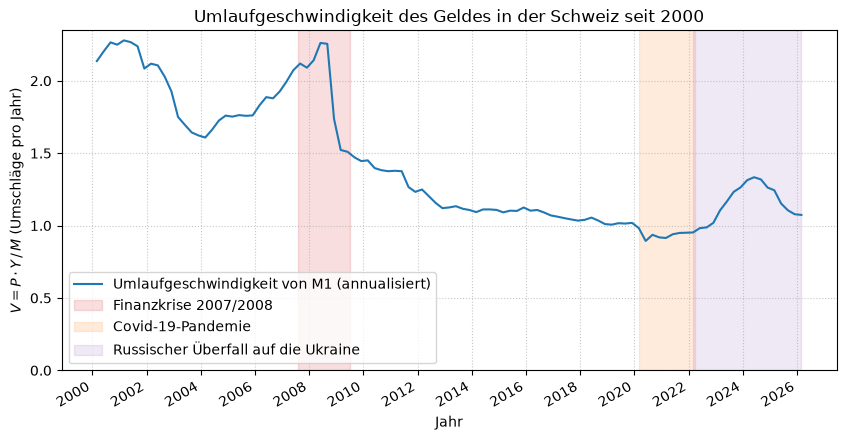

In [14]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(df['Datum'], df['V'], color='tab:blue',
        label='Umlaufgeschwindigkeit von M1 (annualisiert)')

# Krisenzeiträume als vertikale Streifen hervorheben.
# axvspan(xmin, xmax) erwartet zwei x-Werte; pd.Timestamp erzeugt daraus Datumswerte.
ax.axvspan(pd.Timestamp('2007-08-01'), pd.Timestamp('2009-06-30'),
           color='tab:red', alpha=0.15, label='Finanzkrise 2007/2008')
ax.axvspan(pd.Timestamp('2020-03-01'), pd.Timestamp('2022-04-01'),
           color='tab:orange', alpha=0.15, label='Covid-19-Pandemie')
ax.axvspan(pd.Timestamp('2022-02-24'), df['Datum'].max(),
           color='tab:purple', alpha=0.15, label='Russischer Überfall auf die Ukraine')

ax.set_title('Umlaufgeschwindigkeit des Geldes in der Schweiz seit 2000')
ax.set_xlabel('Jahr')
ax.set_ylabel('$V = P \\cdot Y \\, / \\, M$ (Umschläge pro Jahr)')

ax.xaxis.set_major_locator(mdates.YearLocator(2))          # alle zwei Jahre ein Tick
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))   # nur die Jahreszahl anzeigen
ax.set_ylim(bottom=0)                                      # y-Achse beginnt bei 0
ax.grid(True, linestyle=':', alpha=0.7)
ax.legend()

fig.autofmt_xdate()  # Jahreszahlen leicht drehen, damit sie sich nicht überlappen
plt.show()

## 6 Interpretation und Fazit

Die Grafik zeigt einen klaren Befund: Die Umlaufgeschwindigkeit von M1 ist in der Schweiz seit der Jahrtausendwende von gut 2 auf rund 1 Umschlag pro Jahr gesunken – sie hat sich also ungefähr halbiert. Die Quantitätstheorie unterstellt in ihrer einfachen Form ein stabiles $V$ (vgl. Samuelson/Nordhaus). Für die Schweiz seit 2000 trifft diese Annahme offensichtlich nicht zu.

Die hervorgehobenen Krisenzeiträume erlauben zudem eine erste Einschätzung der Hypothese: Weder nach der Finanzkrise noch nach der Pandemie ist ein Anstieg von $V$ erkennbar – im Gegenteil beschleunigt sich der Rückgang jeweils in und nach den Krisen. Die Hypothese, dass die Umlaufgeschwindigkeit nach wirtschaftlichen Krisen steigt, wird durch die Schweizer Daten somit nicht gestützt.

### Limitationen

Zu jeder Data-Science-Arbeit gehört die Frage, wo ihre Grenzen liegen. Das Benennen von Limitationen ist keine Schwäche, sondern ein Qualitätsmerkmal. Für dieses Beispiel sind mindestens drei Punkte zu nennen:

- **Wahl der Geldmenge:** M1 ist eine enge Definition der Geldmenge (Bargeld, Sichteinlagen, Transaktionskonten). Mit M2 oder M3 fiele die berechnete Umlaufgeschwindigkeit anders aus. Die Wahl von M1 ist eine Vereinfachung und müsste in einer grösseren Arbeit begründet oder variiert werden.
- **LIK als Näherung für das Preisniveau:** In der Quantitätsgleichung steht $P$ für das Preisniveau der gesamten inländischen Produktion. Der LIK misst aber nur die Konsumentenpreise. Genauer wäre der BIP-Deflator; der LIK ist eine pragmatische, aber unvollkommene Näherung (vgl. Samuelson/Nordhaus zur Messung des Preisniveaus).
- **Korrelation ist keine Kausalität:** Die Grafik zeigt, dass der Rückgang von $V$ zeitlich mit den Krisen zusammenfällt. Ob die Krisen den Rückgang *verursachen* – etwa über eine erhöhte Geldhaltung aus Vorsichtsmotiven oder über die Tiefzinspolitik der Nationalbank –, lässt sich aus der Grafik allein nicht ableiten.

## 7 Quellen

- Schweizerische Nationalbank, [Datenportal, Monetäre Aggregate](https://data.snb.ch/de/topics/snb/cube/snbmonagg) (Geldmenge M1)
- Staatssekretariat für Wirtschaft SECO, [Bruttoinlandprodukt, Quartalsschätzungen](https://www.seco.admin.ch/de/bruttoinlandprodukt#Tabellen) (reales BIP)
- Bundesamt für Statistik, Landesindex der Konsumentenpreise (LIK)
- [Pandas-Dokumentation](https://pandas.pydata.org/docs/)
- [Matplotlib-Dokumentation](https://matplotlib.org/stable/)
- Samuelson, P. A. / Nordhaus, W. D.: Volkswirtschaftslehre (Quantitätsgleichung, Geldnachfrage, Konjunkturzyklus)

## 8 KI-Deklaration

Diese Vorlage wurde mit Unterstützung von Claude (Anthropic, Juli 2026)
erstellt. Die Unterstützung umfasste: die Hervorhebung der
Krisenzeiträume in der Grafik (Kapitel 5), das Kapitel «Aufbau einer
Data-Science-Arbeit», den Abschnitt «Limitationen» (Kapitel 6) sowie die
Nummerierung der Kapitel. Fragestellung, Datenauswahl, Berechnungsweg
und ökonomische Einordnung stammen vom Autor. Sämtliche KI-erzeugten
Code- und Textteile wurden geprüft; das Notebook wurde abschliessend
vollständig neu ausgeführt. 

*Hinweis für die eigene Arbeit*: Ersetzen Sie diesen Abschnitt durch
Ihre eigene Deklaration. Geben Sie an, welches Werkzeug Sie wofür eingesetzt
haben (z.B. Code-Erstellung, Fehlersuche, Textüberarbeitung,
Strukturierung) und welche Kapitel betroffen sind. Pauschale Angaben
genügen nicht. Eine KI ist keine zitierfähige Quelle: Übernommene Fakten
müssen mit einer überprüfbaren Quelle belegt werden. **Die Verantwortung
für alle Inhalte der Arbeit bleibt bei Ihnen.**